# Wildfire Analysis in Madagascar
Analyzing active fire detections from NASA FIRMS VIIRS satellite. An investigation of fire intensity across the island's seven ecoregions using Fire Radiative Power(FRP) and brightness temperature difference(ΔT = Ti4 - Ti5)


In [1]:
import sys
import os
import geopandas as gpd
from pathlib import Path
from IPython.display import display
import matplotlib.patches as mpatches
from dotenv import load_dotenv

sys.path.append(os.path.abspath('..'))
load_dotenv('../.env')

from wildfire_utils import fetch_data, prepare_fires, region_analysis, build_map

map_key = os.getenv("NASA_MAP_KEY")
data_dir = Path('../data')
output_dir = Path('../outputs')


# Data Collection
Data fetched from API for the last two days.
The gobal dataset is then filtered to Madagascar and gets enriched via the ecoregion information dataset

In [3]:
world= gpd.read_file(data_dir/'ne_10m_admin_0_countries.shp')
madagascar = world[world['NAME'] == 'Madagascar']

fires_gdf = fetch_data(map_key)
ecoregions= gpd.read_file(data_dir/'ecoregions2017_madagascar.gpkg')
fires_madagascar= prepare_fires(fires_gdf, madagascar, ecoregions)


200

latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
19.40287,-155.27623,343.95,0.55,0.51,2026-05-20,11,N,VIIRS,n,2.0NRT,304.32,10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29077 entries, 0 to 29076
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    29077 non-null  float64
 1   longitude   29077 non-null  float64
 2   bright_ti4  29077 non-null  float64
 3   scan        29077 non-null  float64
 4   track       29077 non-null  float64
 5   acq_date    29077 non-null  object 
 6   acq_time    29077 non-null  int64  
 7   satellite   29077 non-null  object 
 8   instrument  29077 non-null  object 
 9   confidence  29077 non-null  object 
 10  version     29077 non-null  object 
 11  bright_ti5  29077 non-null  float64
 12  frp         29077 non-null  float64
 13  daynight    29077 non-null  object 
dtypes: float64(7), int64(1),

# Regional Fire Intensity Analysis
Comparison of fire intensity using mean FRP and ΔT (temp_diff) across the different ecoregions.

Correlation btw FRP and temp_diff: 0.41917788229302194

                                       frp  temp_diff
ecoregion                                            
Madagascar dry deciduous forests  5.654068  39.062000
Madagascar humid forests          4.869091  37.184545
Madagascar mangroves              8.200000  42.600000
Madagascar spiny thickets         6.774545  45.111818
Madagascar subhumid forests       6.450182  35.663758
Madagascar succulent woodlands    6.408987  44.828228


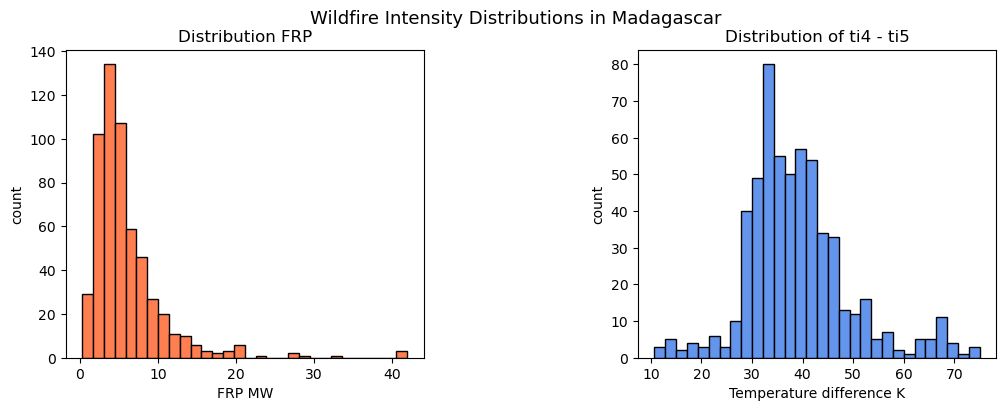

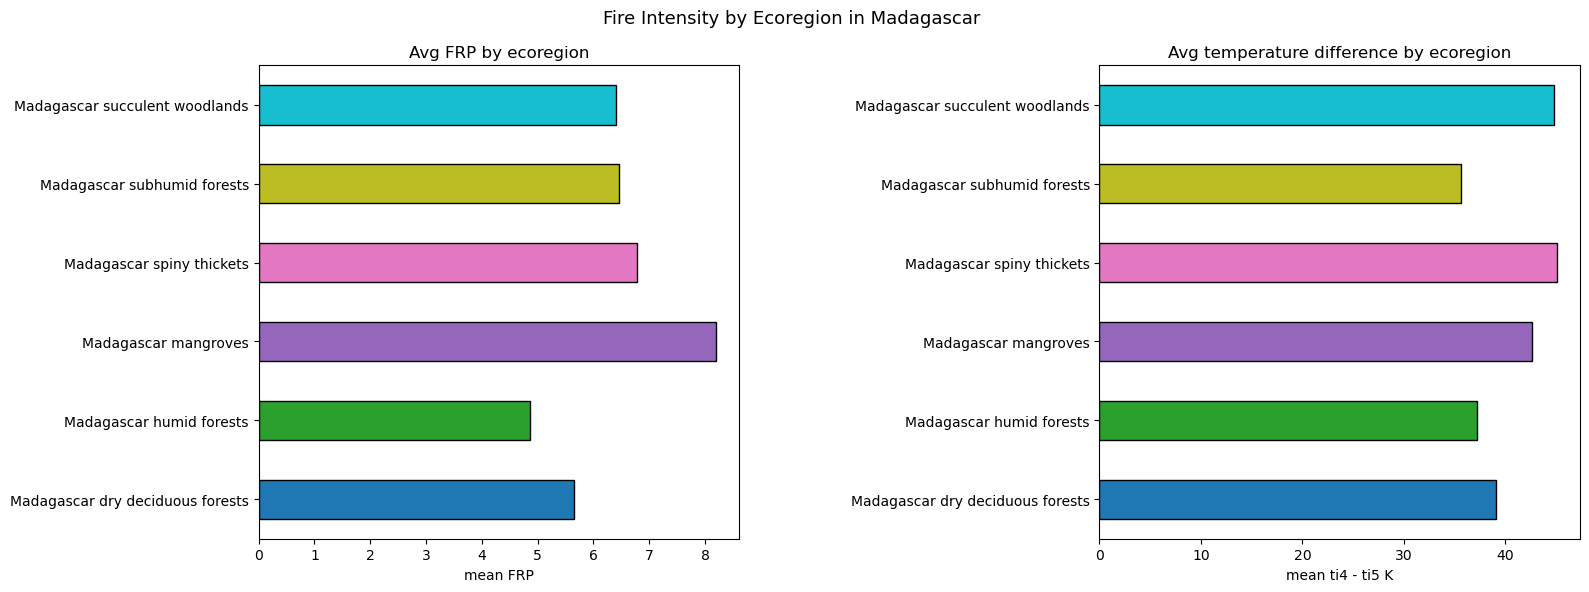

In [4]:
region_stats = region_analysis(fires_madagascar)

# Interactive Folium Map
The map shows fire intensity, density and  spatial distribution.
Using the layer control (top right) you can switch between:
- Ecoregions: 7 ecologigal zones of Madagascar
- Intensity: circle size = FRP, circle color = temperature difference
- Wildfire Clusters: zoomed out overwiew of fire locations
- Heatmap: fire density weighted by FRP

In [5]:
m = build_map(fires_madagascar, madagascar, ecoregions)
m.save(output_dir/'wildfire_map.html')
m

Center of Madagascar:(-19.314007703204048, 46.74456026925646)

